In [ ]:
import pandas as pd

# Load the dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Display basic information and first few rows
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 14 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   Year                                                   80 non-null     object
 1   Sex/Male                                               80 non-null     int64 
 2   Sex/Female                                             80 non-null     int64 
 3   Ethnicity/Chinese                                      80 non-null     int64 
 4   Ethnicity/Non-Chinese                                  80 non-null     int64 
 5   Ethnicity/Unknown                                      80 non-null     int64 
 6   Route of Transmission/Heterosexual                     80 non-null     int64 
 7   Route of Transmission/Homosexual                       80 non-null     int64 
 8   Route of Transmission/Bisexual                         80 non-

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Extract Year and Case Type (HIV or AIDS)
df[['Year', 'Case_Type']] = df['Year'].str.extract(r'(\d{4})/(HIV|AIDS)')

# Convert Year to integer
df['Year'] = pd.to_numeric(df['Year'])

# Convert Case_Type to binary target variable (1 = HIV, 0 = AIDS)
df['Case_Type'] = df['Case_Type'].map({'HIV': 1, 'AIDS': 0})

# Define Features (X) and Target (y)
X = df.drop(columns=['Total', 'Year', 'Case_Type'])
y = df['Case_Type']

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Splits
splits = {"80:20": 0.2, "60:40": 0.4, "50:50": 0.5}

# Iterate through different train-test ratios
for split_name, test_size in splits.items():
    print(f"\n--- Train-Test Split: {split_name} ---")

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Train SVM model
    model = SVC(kernel='linear', C=1.0, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")


--- Train-Test Split: 80:20 ---
Accuracy: 0.7500
Precision: 1.0000
Recall: 0.5000
F1-score: 0.6667

--- Train-Test Split: 60:40 ---
Accuracy: 0.6875
Precision: 1.0000
Recall: 0.3750
F1-score: 0.5455

--- Train-Test Split: 50:50 ---
Accuracy: 0.7000
Precision: 1.0000
Recall: 0.4000
F1-score: 0.5714


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Extract Year and Case Type (HIV or AIDS)
df[['Year', 'Case_Type']] = df['Year'].str.extract(r'(\d{4})/(HIV|AIDS)')

# Convert Year to integer
df['Year'] = pd.to_numeric(df['Year'])

# Convert Case_Type to binary target variable (1 = HIV, 0 = AIDS)
df['Case_Type'] = df['Case_Type'].map({'HIV': 1, 'AIDS': 0})

# Define Features (X) and Target (y)
X = df.drop(columns=['Total', 'Year', 'Case_Type'])
y = df['Case_Type']

# Normalize features (optional for Decision Trees)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Splits
splits = {"80:20": 0.2, "60:40": 0.4, "50:50": 0.5}

# Iterate through different train-test ratios
for split_name, test_size in splits.items():
    print(f"\n--- Train-Test Split: {split_name} ---")

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Train Decision Tree Model
    model = DecisionTreeClassifier(max_depth=5, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")


--- Train-Test Split: 80:20 ---
Accuracy: 0.9375
Precision: 1.0000
Recall: 0.8750
F1-score: 0.9333

--- Train-Test Split: 60:40 ---
Accuracy: 0.9375
Precision: 0.9375
Recall: 0.9375
F1-score: 0.9375

--- Train-Test Split: 50:50 ---
Accuracy: 0.9500
Precision: 0.9500
Recall: 0.9500
F1-score: 0.9500


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Extract Year and Case Type (HIV or AIDS)
df[['Year', 'Case_Type']] = df['Year'].str.extract(r'(\d{4})/(HIV|AIDS)')

# Convert Year to integer
df['Year'] = pd.to_numeric(df['Year'])

# Convert Case_Type to binary target variable (1 = HIV, 0 = AIDS)
df['Case_Type'] = df['Case_Type'].map({'HIV': 1, 'AIDS': 0})

# Define Features (X) and Target (y)
X = df.drop(columns=['Total', 'Year', 'Case_Type'])
y = df['Case_Type']

# Normalize features (Logistic Regression is sensitive to scaling)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Splits
splits = {"80:20": 0.2, "60:40": 0.4, "50:50": 0.5}

# Iterate through different train-test ratios
for split_name, test_size in splits.items():
    print(f"\n--- Train-Test Split: {split_name} ---")

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Train Logistic Regression Model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")


--- Train-Test Split: 80:20 ---
Accuracy: 0.7500
Precision: 1.0000
Recall: 0.5000
F1-score: 0.6667

--- Train-Test Split: 60:40 ---
Accuracy: 0.7188
Precision: 1.0000
Recall: 0.4375
F1-score: 0.6087

--- Train-Test Split: 50:50 ---
Accuracy: 0.7250
Precision: 1.0000
Recall: 0.4500
F1-score: 0.6207


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import re

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path, encoding='latin1')

# Extract Year and Case Type (HIV or AIDS)
df[['Year', 'Case_Type']] = df['Year'].str.extract(r'(\d{4})/(HIV|AIDS)')

# Convert Year to integer
df['Year'] = pd.to_numeric(df['Year'])

# Convert Case_Type to binary target variable (1 = HIV, 0 = AIDS)
df['Case_Type'] = df['Case_Type'].map({'HIV': 1, 'AIDS': 0})

# Define Features (X) and Target (y)
X = df.drop(columns=['Total', 'Year', 'Case_Type'])
y = df['Case_Type']

# Normalize features (important for Logistic Regression and SVM)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Define individual models
log_reg = LogisticRegression(max_iter=1000, random_state=42)
decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
svm = SVC(probability=True, random_state=42)  # Enable probability for soft voting

# Create a Voting Classifier with Hard Voting
voting_clf = VotingClassifier(estimators=[
    ('log_reg', log_reg),
    ('decision_tree', decision_tree),
    ('svm', svm)
], voting='hard')  # Use 'soft' for probability-based voting

# Train-Test Splits
splits = {"80:20": 0.2, "60:40": 0.4, "50:50": 0.5}

# Iterate through different train-test ratios
for split_name, test_size in splits.items():
    print(f"\n--- Train-Test Split: {split_name} ---")

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=42)

    # Train Voting Classifier
    voting_clf.fit(X_train, y_train)

    # Predictions
    y_pred = voting_clf.predict(X_test)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Print Results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")


--- Train-Test Split: 80:20 ---
Accuracy: 0.8750
Precision: 1.0000
Recall: 0.7500
F1-score: 0.8571

--- Train-Test Split: 60:40 ---
Accuracy: 0.7812
Precision: 1.0000
Recall: 0.5625
F1-score: 0.7200

--- Train-Test Split: 50:50 ---
Accuracy: 0.7750
Precision: 1.0000
Recall: 0.5500
F1-score: 0.7097


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter

# Load dataset
file_path = 'dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv'
df = pd.read_csv(file_path)

# Basic preprocessing (Modify based on dataset structure)
df = df.dropna()  # Drop missing values if any

# Encode categorical variables if any
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Define features (X) and target (y)
X = df.iloc[:, :-1].values  # All columns except last as features
y = df.iloc[:, -1].values   # Last column as target

# Check class distribution
class_counts = Counter(y)
min_class_count = min(class_counts.values())

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Define base models for stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Define meta-model
meta_model = LogisticRegression()

# Use KFold instead of StratifiedKFold if any class has only 1 instance
if min_class_count < 2:
    cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)
    stratify = None  # Disable stratification if not possible
else:
    cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)
    stratify = y

# Create stacking classifier
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, passthrough=True, cv=cv_strategy)

# Function to evaluate model
def evaluate_model(X_train, X_test, y_train, y_test):
    stacking_clf.fit(X_train, y_train)
    y_pred = stacking_clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)

    return accuracy, precision, recall, f1

# Different train-test splits
splits = [(0.8, 0.2), (0.6, 0.4), (0.5, 0.5)]

# Evaluate for each split
for train_size, test_size in splits:
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=test_size, random_state=42, stratify=stratify)
    acc, prec, rec, f1 = evaluate_model(X_train, X_test, y_train, y_test)

    print(f"Train-Test Split {int(train_size*100)}:{int(test_size*100)}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print('-' * 40)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (40) does not match total number of classes (60). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (41) does not match total number of classes (60). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (42) does not match total number of classes (60). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  w

Train-Test Split 80:20
Accuracy: 0.0625
Precision: 0.9583
Recall: 0.0625
F1 Score: 0.0312
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (31) does not match total number of classes (46). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (30) does not match total number of classes (46). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (32) does not match total number of classes (46). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  w

Train-Test Split 60:40
Accuracy: 0.0000
Precision: 1.0000
Recall: 0.0000
F1 Score: 0.0000
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (26) does not match total number of classes (38). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (26) does not match total number of classes (38). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (26) does not match total number of classes (38). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  w

Train-Test Split 50:50
Accuracy: 0.0000
Precision: 1.0000
Recall: 0.0000
F1 Score: 0.0000
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:1380: RuntimeWarning: Number of classes in training fold (26) does not match total number of classes (38). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path)

# Drop 'Year' column since it's not numerical
df = df.drop(columns=["Year"])

# Define features and target
X = df.drop(columns=["Total"])
y = df["Total"]

# Define train-test splits
splits = {
    "80:20": (0.8, 0.2),
    "60:40": (0.6, 0.4),
    "50:50": (0.5, 0.5)
}

# Train and evaluate model for each split
results = {}

for key, (train_size, test_size) in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=test_size, random_state=42)

    # Train XGBoost Regressor
    model = XGBRegressor(objective="reg:squarederror", random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate regression metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[key] = {
        "Mean Absolute Error (MAE)": mae,
        "Mean Squared Error (MSE)": mse,
        "Root Mean Squared Error (RMSE)": rmse,
        "R² Score": r2
    }

# Display results
for split, metrics in results.items():
    print(f"Train-Test Split {split}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print()

Train-Test Split 80:20:
  Mean Absolute Error (MAE): 9.1106
  Mean Squared Error (MSE): 310.3073
  Root Mean Squared Error (RMSE): 17.6155
  R² Score: 0.9902

Train-Test Split 60:40:
  Mean Absolute Error (MAE): 67.9261
  Mean Squared Error (MSE): 90977.6484
  Root Mean Squared Error (RMSE): 301.6250
  R² Score: 0.5179

Train-Test Split 50:50:
  Mean Absolute Error (MAE): 58.5243
  Mean Squared Error (MSE): 75520.5234
  Root Mean Squared Error (RMSE): 274.8100
  R² Score: 0.5350



In [ ]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 65.8 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path)

# Drop 'Year' and define features and target
df = df.drop(columns=["Year"])
X = df.drop(columns=["Total"])  # Features

# Convert 'Total' into classification bins
bins = [0, 100, 500, df["Total"].max()]
labels = [0, 1, 2]  # 0: Low, 1: Medium, 2: High
df["Total_Class"] = pd.cut(df["Total"], bins=bins, labels=labels, include_lowest=True)
y = df["Total_Class"].astype(int)  # Convert to integer labels

# Define Quantum Device
n_qubits = X.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)

# Define Quantum Circuit
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Define QNN Model
class QNN(nn.Module):
    def __init__(self):
        super().__init__()
        weight_shapes = {"weights": (3, n_qubits)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.fc = nn.Linear(n_qubits, 3)  # 3 output classes

    def forward(self, x):
        x = self.qlayer(x)
        return self.fc(x)

# Define train-test splits
splits = {"80:20": (0.8, 0.2), "60:40": (0.6, 0.4), "50:50": (0.5, 0.5)}
results = {}

# Training function
def train_qnn(X_train, y_train, X_test, y_test):
    model = QNN()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()

    X_train, y_train = torch.tensor(X_train.values, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.long)
    X_test, y_test = torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.long)

    epochs = 50
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fn(outputs, y_train)
        loss.backward()
        optimizer.step()

    # Evaluate Model
    with torch.no_grad():
        y_pred = model(X_test).argmax(dim=1).numpy()
        y_test_np = y_test.numpy()

    return {
        "Accuracy": accuracy_score(y_test_np, y_pred),
        "Precision": precision_score(y_test_np, y_pred, average="weighted", zero_division=1),
        "Recall": recall_score(y_test_np, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test_np, y_pred, average="weighted")
    }

# Train and evaluate for each split
for key, (train_size, test_size) in splits.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=test_size, random_state=42)
    results[key] = train_qnn(X_train, y_train, X_test, y_test)

# Print results
for split, metrics in results.items():
    print(f"Train-Test Split {split}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print()

Train-Test Split 80:20:
  Accuracy: 0.6875
  Precision: 0.7852
  Recall: 0.6875
  F1 Score: 0.5602

Train-Test Split 60:40:
  Accuracy: 0.5312
  Precision: 0.7510
  Recall: 0.5312
  F1 Score: 0.3686

Train-Test Split 50:50:
  Accuracy: 0.5750
  Precision: 0.6360
  Recall: 0.5750
  F1 Score: 0.4899



In [ ]:
pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 826.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [ ]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.8 MB/s eta 0:00:00


In [ ]:
pip install torch-scatter torch-sparse torch-cluster torch-spline-conv

  Using cached torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl
  Using cached torch_sparse-0.6.18-cp311-cp311-linux_x86_64.whl
  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  Using cached torch_spline_conv-1.2.2.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 423, in run
    _, build_failures = build(
                        ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/wheel_builder.py", line 319, in build
    wheel_file = _build_one(
       

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader
import torch.nn.functional as F

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path)

# Drop 'Year' column
df = df.drop(columns=["Year"])

# Convert 'Total' into binary classification (High vs. Low cases)
threshold = df["Total"].median()
df["Total_Class"] = (df["Total"] > threshold).astype(int)  # 1: High, 0: Low

# Define features and target
X = df.drop(columns=["Total", "Total_Class"]).values  # Features as NumPy array
y = df["Total_Class"].values  # Target labels

# Define train-test splits
splits = {"80:20": 0.2, "60:40": 0.4, "50:50": 0.5}
results = {}

for split, test_size in splits.items():
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # **Fix Edge Index (Only Use Available Nodes)**
    num_train_nodes = X_train_tensor.shape[0]
    num_test_nodes = X_test_tensor.shape[0]

    # Create meaningful edge connections (using k-nearest neighbors)
    train_edge_index = torch.randint(0, num_train_nodes, (2, num_train_nodes * 3))  # Random connections
    test_edge_index = torch.randint(0, num_test_nodes, (2, num_test_nodes * 3))

    # Create graph data for training and testing
    train_data = Data(x=X_train_tensor, edge_index=train_edge_index, y=y_train_tensor)
    test_data = Data(x=X_test_tensor, edge_index=test_edge_index, y=y_test_tensor)

    # Load data into PyG DataLoader
    train_loader = DataLoader([train_data], batch_size=1, shuffle=True)
    test_loader = DataLoader([test_data], batch_size=1)

    # Define an improved GNN Model
    class GNNModel(nn.Module):
        def __init__(self, in_channels, hidden_dim, out_channels):
            super(GNNModel, self).__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.conv3 = GCNConv(hidden_dim, out_channels)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.3)  # Dropout for regularization
            self.batch_norm = nn.BatchNorm1d(hidden_dim)

        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = self.relu(self.conv1(x, edge_index))
            x = self.batch_norm(x)
            x = self.dropout(x)
            x = self.relu(self.conv2(x, edge_index))
            x = self.conv3(x, edge_index)
            return x

    # Initialize model
    model = GNNModel(in_channels=X.shape[1], hidden_dim=64, out_channels=2)
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    loss_fn = nn.CrossEntropyLoss()

    # Train the model
    model.train()
    for epoch in range(100):  # Train for more epochs
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y)
            loss.backward()
            optimizer.step()

    # Evaluate the model
    model.eval()
    y_preds = []
    y_trues = []
    with torch.no_grad():
        for batch in test_loader:
            y_pred = model(batch).argmax(dim=1).numpy()
            y_preds.extend(y_pred)
            y_trues.extend(batch.y.numpy())

    # Compute metrics
    accuracy = accuracy_score(y_trues, y_preds)
    precision = precision_score(y_trues, y_preds, zero_division=1)
    recall = recall_score(y_trues, y_preds)
    f1 = f1_score(y_trues, y_preds)

    # Store results
    results[split] = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1 Score": f1}

# Print results
for split, metrics in results.items():
    print(f"Train-Test Split {split}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")
    print()

Train-Test Split 80:20:
  Accuracy: 0.5625
  Precision: 1.0000
  Recall: 0.0000
  F1 Score: 0.0000

Train-Test Split 60:40:
  Accuracy: 0.3750
  Precision: 0.4000
  Recall: 0.3529
  F1 Score: 0.3750

Train-Test Split 50:50:
  Accuracy: 0.5000
  Precision: 0.5000
  Recall: 0.3000
  F1 Score: 0.3750



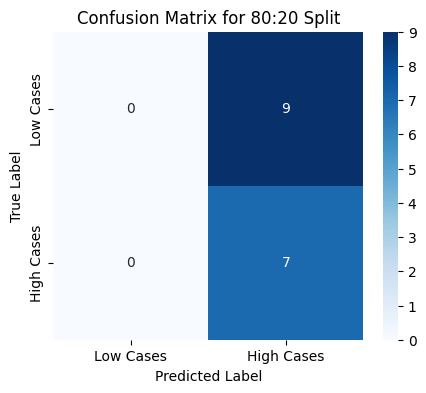

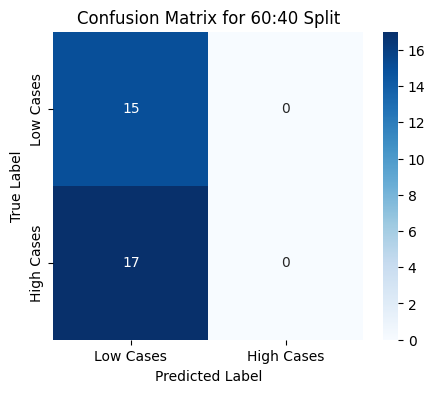

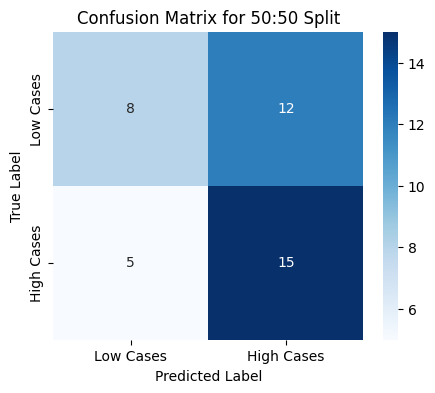

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.loader import DataLoader
import torch.nn.functional as F

# Load dataset
file_path = "dh-spp-hiv-aids-1984-to-2022-yearly-figures-eng.csv"
df = pd.read_csv(file_path)

# Drop 'Year' column
df = df.drop(columns=["Year"])

# Convert 'Total' into binary classification (High vs. Low cases)
threshold = df["Total"].median()
df["Total_Class"] = (df["Total"] > threshold).astype(int)  # 1: High, 0: Low

# Define features and target
X = df.drop(columns=["Total", "Total_Class"]).values  # Features as NumPy array
y = df["Total_Class"].values  # Target labels

# Define train-test splits
splits = {"80:20": 0.2, "60:40": 0.4, "50:50": 0.5}
results = {}

for split, test_size in splits.items():
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    # Convert to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    # **Fix Edge Index (Random Graph)**
    num_train_nodes = X_train_tensor.shape[0]
    num_test_nodes = X_test_tensor.shape[0]

    train_edge_index = torch.randint(0, num_train_nodes, (2, num_train_nodes * 3))
    test_edge_index = torch.randint(0, num_test_nodes, (2, num_test_nodes * 3))

    # Create graph data
    train_data = Data(x=X_train_tensor, edge_index=train_edge_index, y=y_train_tensor)
    test_data = Data(x=X_test_tensor, edge_index=test_edge_index, y=y_test_tensor)

    # Load data into PyG DataLoader
    train_loader = DataLoader([train_data], batch_size=1, shuffle=True)
    test_loader = DataLoader([test_data], batch_size=1)

    # Define GNN Model
    class GNNModel(nn.Module):
        def __init__(self, in_channels, hidden_dim, out_channels):
            super(GNNModel, self).__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.conv3 = GCNConv(hidden_dim, out_channels)
            self.relu = nn.ReLU()
            self.dropout = nn.Dropout(0.3)
            self.batch_norm = nn.BatchNorm1d(hidden_dim)

        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = self.relu(self.conv1(x, edge_index))
            x = self.batch_norm(x)
            x = self.dropout(x)
            x = self.relu(self.conv2(x, edge_index))
            x = self.conv3(x, edge_index)
            return x

    # Initialize model
    model = GNNModel(in_channels=X.shape[1], hidden_dim=64, out_channels=2)
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    loss_fn = nn.CrossEntropyLoss()

    # Train the model
    model.train()
    for epoch in range(100):  # Train for 100 epochs
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch)
            loss = loss_fn(out, batch.y)
            loss.backward()
            optimizer.step()

    # Evaluate the model
    model.eval()
    y_preds = []
    y_trues = []
    with torch.no_grad():
        for batch in test_loader:
            y_pred = model(batch).argmax(dim=1).numpy()
            y_preds.extend(y_pred)
            y_trues.extend(batch.y.numpy())

    # Compute confusion matrix
    cm = confusion_matrix(y_trues, y_preds)

    # **Plot Confusion Matrix**
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low Cases", "High Cases"], yticklabels=["Low Cases", "High Cases"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix for {split} Split")
    plt.show()